# Coucou AI

How to play: [https://en.wikipedia.org/wiki/Coucou](https://en.wikipedia.org/wiki/Coucou)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

In [2]:
numbers = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K']
cards = [
    f"{number}{suit}" for suit in ['♠', '♥', '♦', '♣'] for number in numbers
]

In [3]:
def card_int(card_number):
    if card_number == 'A':
        return 1
    if card_number in ['J', 'Q', 'K']:
        return 11 + ['J', 'Q', 'K'].index(card_number)
    return int(card_number)

In [4]:
def inizialize_ai():
    global ai, ai_simplified
    ai = {
        (card_int(x), card_int(y)): 0 for x in numbers for y in numbers # (after_swap_card, pre_swap_card)
    }
    ai_simplified = {
        card_int(x): 0 for x in numbers
    }

In [5]:
def ai_choice(curr_number, initial_number):
    if curr_number > initial_number:
        return -1 # stay
    return ai_simplified[curr_number] > 0 # logistic regression

In [6]:
def ai_choice_final(curr_number, initial_number):
    if curr_number > initial_number:
        return -1 # stay
    return ai_simplified[curr_number] > 0 # logistic regression

In [7]:
def cpu_choice(number):
    global n_players
    if n_players <= 2:
        return number < 7
    if n_players <= 4:
        return number < 5
    if n_players <= 5:
        return number < 4
    if n_players <= 10:
        return number < 3
    return number < 2

In [8]:
def cpu_choice_final(number):
    global n_players
    if n_players <= 2:
        return number < 7
    if n_players <= 4:
        return number < 4
    if n_players <= 5:
        return number < 3
    return number < 2

In [9]:
def play(train=False, log=False):
    global n_players
    random.shuffle(cards)
    ai_position = random.randint(0, n_players-1)
    swap = 0
    players = [[cards[i], cards[i]] for i in range(n_players)] # [curr_card, prev_card]
    for i in range(n_players-1):
        if i == ai_position:
            swap = ai_choice(card_int(players[i][0][:-1]), card_int(players[i][1][:-1]))
            if swap == 1:
                players[i][1] = players[i][0]
                players[i][0], players[i+1][0] = players[i+1][0], players[i][0]
            else:
                players[i][1] = players[i][0]
        else:
            if card_int(players[i][0][:-1]) <= card_int(players[i][1][:-1]) and cpu_choice(card_int(players[i][0][:-1])):
                players[i][1] = players[i][0]
                players[i][0], players[i+1][0] = players[i+1][0], players[i][0]
            else:
                players[i][1] = players[i][0]
    if ai_position == n_players-1:
        swap = ai_choice_final(card_int(players[-1][0][:-1]), card_int(players[-1][1][:-1]))
        if swap == 1:
            players[-1][1] = players[-1][0]
            n = random.randint(1, len(cards) - n_players)
            players[-1][0] = cards[n_players + n - 1]
        else:
            players[-1][1] = players[-1][0]
    elif card_int(players[-1][0][:-1]) <= card_int(players[-1][1][:-1]) and cpu_choice_final(card_int(players[-1][0][:-1])):
        players[-1][1] = players[-1][0]
        n = random.randint(1, len(cards) - n_players)
        players[-1][0] = cards[n_players + n - 1]
    min_card = card_int(players[0][0][:-1])
    min_idxs = [0]
    for i in range(1, n_players):
        if card_int(players[i][0][:-1]) < min_card:
            min_card = card_int(players[i][0][:-1])
            min_idxs = [i]
        elif card_int(players[i][0][:-1]) == min_card:
            min_idxs.append(i)
    if train and swap == -1:
        swap = 0
    if train and swap == 1:
        if card_int(players[ai_position][0][:-1]) > card_int(players[ai_position][1][:-1]):
            ai[card_int(players[ai_position][0][:-1]), card_int(players[ai_position][1][:-1])] += 0.005
            ai_simplified[card_int(players[ai_position][1][:-1])] += 0.005
            if log:
                print(f"Good swap, +{0.05}")
        elif card_int(players[ai_position][0][:-1]) < card_int(players[ai_position][1][:-1]):
            ai[card_int(players[ai_position][0][:-1]), card_int(players[ai_position][1][:-1])] -= 0.005
            ai_simplified[card_int(players[ai_position][1][:-1])] -= 0.005
            if log:
                print(f"Bad swap, -{0.05}")
    if train and ai_position in min_idxs: # lost
        ai[card_int(players[ai_position][0][:-1]), card_int(players[ai_position][1][:-1])] += 0.01 * (0.5 - swap) * 2
        ai_simplified[card_int(players[ai_position][1][:-1])] += 0.01 * (0.5 - swap) * 2
    elif train: # not lost
        ai[card_int(players[ai_position][0][:-1]), card_int(players[ai_position][1][:-1])] -= 0.01 * (0.5 - swap) * 2
        ai_simplified[card_int(players[ai_position][1][:-1])] -= 0.01 * (0.5 - swap) * 2
    if log:
        print(players[ai_position], 'Swapped' if swap == 1 else 'Stay', 'Lost' if ai_position in min_idxs else 'Win')
        print(players)

n_players=3


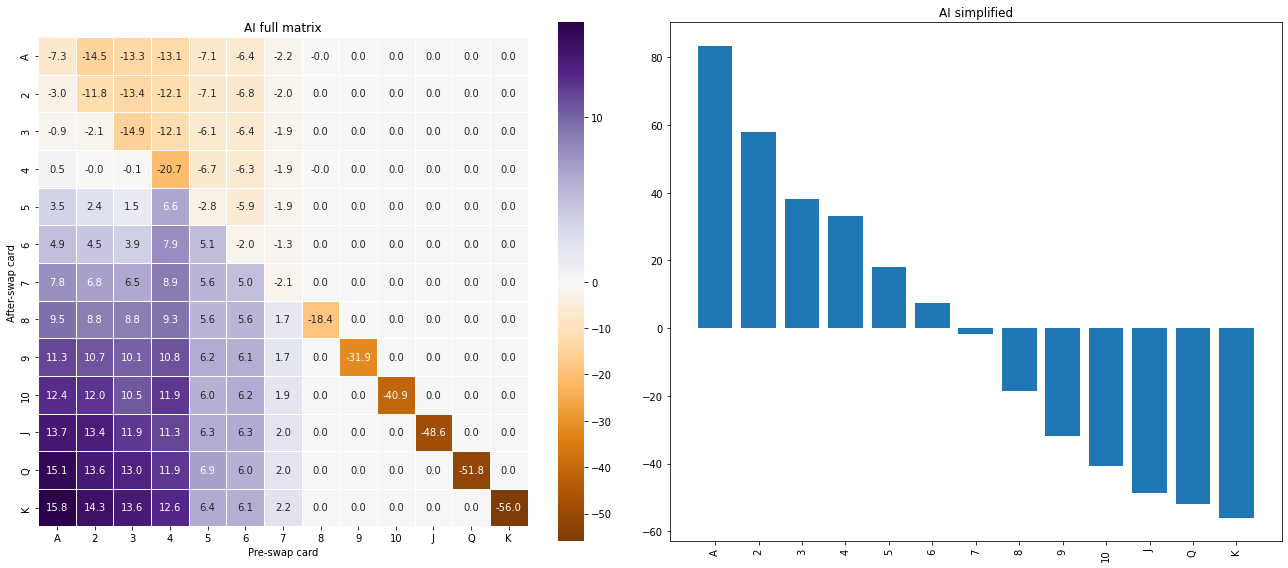

n_players=5


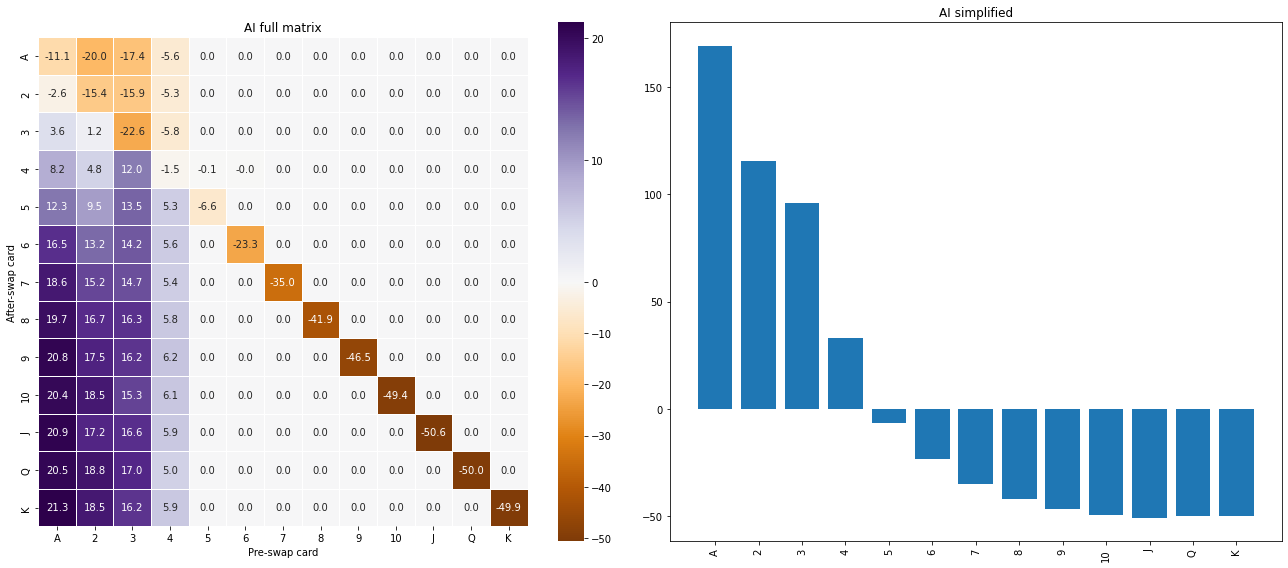

n_players=10


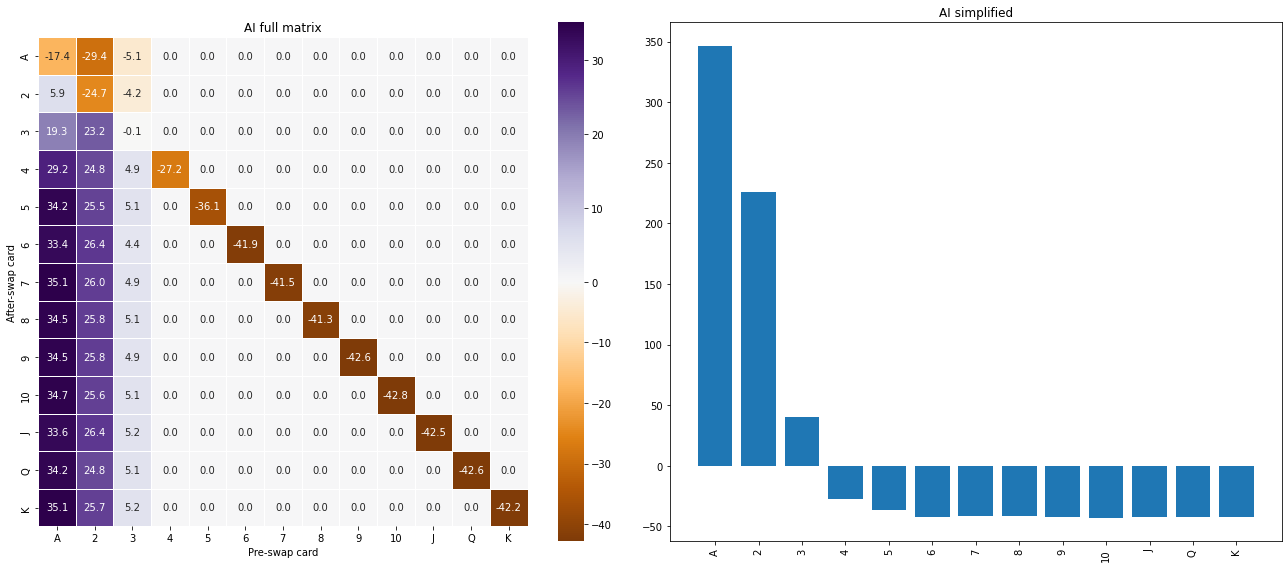

In [12]:
for n_players in [3, 5, 10]:
    print(f"{n_players=}")
    inizialize_ai()
    for _ in range(100_000):
        play(train=True, log=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    data = np.array(list(ai.values())).reshape(13, 13)
    norm = TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=data.max())
    sns.heatmap(
        data,
        annot=True,
        norm=norm,
        fmt='.1f',
        square=True,
        linewidth=1.0,
        cmap="PuOr",
        ax=axes[0]
    )
    axes[0].set_title("AI full matrix")
    axes[0].set_xlabel('Pre-swap card')
    axes[0].set_ylabel('After-swap card')
    axes[0].set_xticklabels(numbers)
    axes[0].set_yticklabels(numbers)
    axes[1].bar([numbers[k-1] for k in ai_simplified.keys()], ai_simplified.values())
    axes[1].set_title("AI simplified")
    axes[1].tick_params(axis="x", rotation=90)
    axes[1].set_xticks(range(len(numbers)))
    axes[1].set_xticklabels(numbers)
    plt.tight_layout()
    plt.show()
